# Statistical Analysis

Objectives

1. Quantify reaction-time differences across congruent, neutral, and incongruent conditions.

2. Estimate the size of Stroop interference at both group and individual levels.

3. Test statistical evidence for interference using within-subject analyses.

4. Check robustness of results using sensitivity analyses and assumption checks.

5. Examine associations between baseline processing speed, accuracy, and interference magnitude.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import (ttest_rel, t, shapiro, wilcoxon)

# Figure Style

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.autolayout"] = True
plt.rcParams["font.size"] = 11
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["savefig.bbox"] = "tight"

palette = {
    "congruent": "#4E79A7",
    "neutral": "#9E9E9E",
    "incongruent": "#E15759",
    "effect": "#E15759"
}

In [2]:
# Loading cleaned data.

file_path = r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\processed\stroop-cleaned.csv"

df = pd.read_csv(file_path)

# Inspection

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 48517 entries, 0 to 48516
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subj       48517 non-null  int64  
 1   trial      48517 non-null  int64  
 2   time       48517 non-null  float64
 3   color      48517 non-null  str    
 4   condition  48517 non-null  str    
 5   correct    48517 non-null  str    
 6   response   48517 non-null  str    
 7   RT         48517 non-null  float64
dtypes: float64(2), int64(2), str(4)
memory usage: 3.0 MB
None
     subj  trial      time  color    condition  correct response        RT
0  118340      0  1.814140  green    congruent  correct        f  0.944198
1  118340      1  3.835822  green  incongruent  correct        f  0.794779
2  118340      2  5.855570    red  incongruent  correct        d  0.566762
3  118340      3  7.875476   blue      neutral  correct        j  0.674958
4  118340      4  9.895955  green      neutral  correct        f 

In [3]:
df = df.copy()

# RT validity filter

df = df[df["RT"] > 0.2]
df = df[df["RT"] < 2.0]

Note: RT validity filter was added to remove technical artifacts and have a standard cognitive preprocessing.

In [4]:
# Defining core conditions.

conditions = ["congruent", "neutral", "incongruent"]

# Checking conditions.

print(df["condition"].value_counts())

condition
congruent      16267
neutral        16218
incongruent    16016
Name: count, dtype: int64


In [5]:
# Grouping participants by conditions.

subj_cond = (
    df.groupby(["subj", "condition"])["RT"]
    .mean()
    .reset_index()
)

# Transforming to wide.

wide = subj_cond.pivot(index="subj", columns="condition", values="RT")

print(wide.head())

condition  congruent  incongruent   neutral
subj                                       
118340      0.671240     0.743216  0.665011
120554      0.612650     0.679864  0.612755
142272      0.623539     0.650803  0.624286
142610      0.818801     0.996469  0.860798
146393      0.695120     0.779653  0.714846


In [6]:
# Computing Stroop interference.

wide["stroop_effect"] = wide["incongruent"] - wide["congruent"]

In [7]:
# Checking effect direction.

wide["stroop_effect"].describe()

count    81.000000
mean      0.106331
std       0.053855
min       0.005288
25%       0.069725
50%       0.097793
75%       0.146348
max       0.231218
Name: stroop_effect, dtype: float64

In [8]:
# Checking condition separation.

wide[["congruent","neutral","incongruent"]].mean()

condition
congruent      0.676423
neutral        0.692964
incongruent    0.782753
dtype: float64

In [9]:
# Participant variability

# Checking variability quantification.

print(wide["stroop_effect"].std())
print(wide["stroop_effect"].mean())

# Identifying extremes.

print(wide.sort_values("stroop_effect").head())
print(wide.sort_values("stroop_effect", ascending=False).head())

0.053855149640765605
0.10633077438679957
condition  congruent  incongruent   neutral  stroop_effect
subj                                                      
360027      0.630773     0.636061  0.625535       0.005288
376613      0.594810     0.617719  0.594319       0.022909
342919      0.611005     0.636791  0.599545       0.025785
430453      0.578210     0.604155  0.559745       0.025945
753332      0.594621     0.621167  0.578729       0.026546
condition  congruent  incongruent   neutral  stroop_effect
subj                                                      
847738      0.730699     0.961916  0.748415       0.231218
684397      0.743703     0.967341  0.811870       0.223638
354109      0.930092     1.147174  0.989465       0.217082
283382      0.750509     0.956095  0.780152       0.205586
668918      0.711770     0.915505  0.742947       0.203734


In [10]:
# Checking accuracy of RT relation.

acc = df.groupby("subj")["correct"].apply(lambda x: (x=="correct").mean())

corr = wide["stroop_effect"].corr(acc)

print(corr)

-0.24520411239475048


In [11]:
# Saving the analictic dataset results.

wide.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\subject-level-stroop-effects.csv")

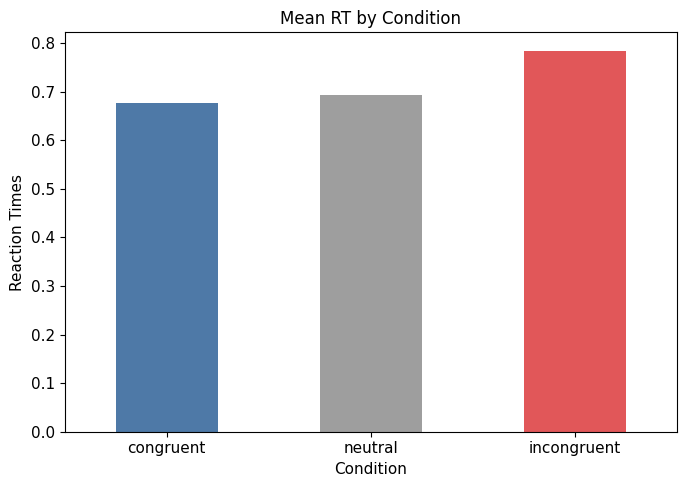

In [12]:
# Visualizing mean RT by condition bar plot.

plt.figure()

mean = wide[["congruent","neutral","incongruent"]].mean()
    
mean.plot(
    kind="bar",
    color=[
        palette["congruent"],
        palette["neutral"],
        palette["incongruent"]
    ]
)

plt.title("Mean RT by Condition")
plt.ylabel("Reaction Times")
plt.xlabel("Condition")
plt.xticks(rotation=0)

plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\rt-by-condition-bar.png")
plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\rt-by-condition-bar.pdf")

plt.show()

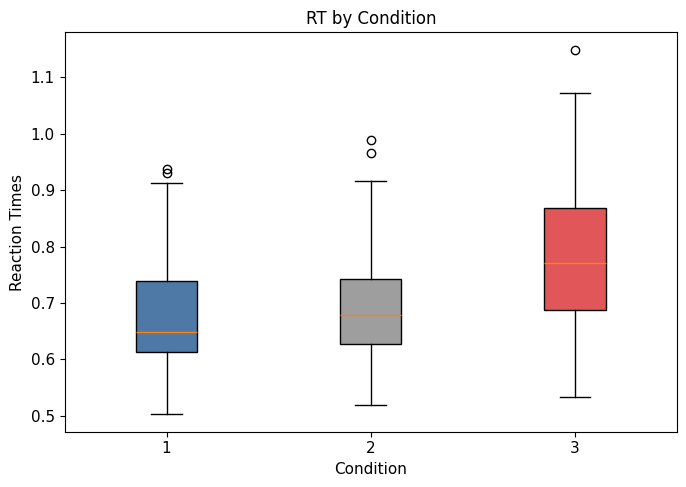

In [13]:
# Visualizing RT by condition box plot.

plt.figure()

box = plt.boxplot(
    [
        wide["congruent"],
        wide["neutral"],
        wide["incongruent"]
    ],
    patch_artist=True
)

for patch, color in zip(
    box["boxes"],
    [
        palette["congruent"],
        palette["neutral"],
        palette["incongruent"]
    ]
):
    patch.set_facecolor(color)

plt.title("RT by Condition")
plt.ylabel("Reaction Times")
plt.xlabel("Condition")

plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\rt-by-condition-box.png")
plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\rt-by-condition-box.pdf")

plt.show()

Note:
- Stroop interference effect is present and directionally stable.
- Effect is consistent across all participants.
- Variability is meaningful and likely reflects both cognitive differences and experimental noise.
- Neutral condition behaves appropriately as an intermediate baseline, but not symmetric.

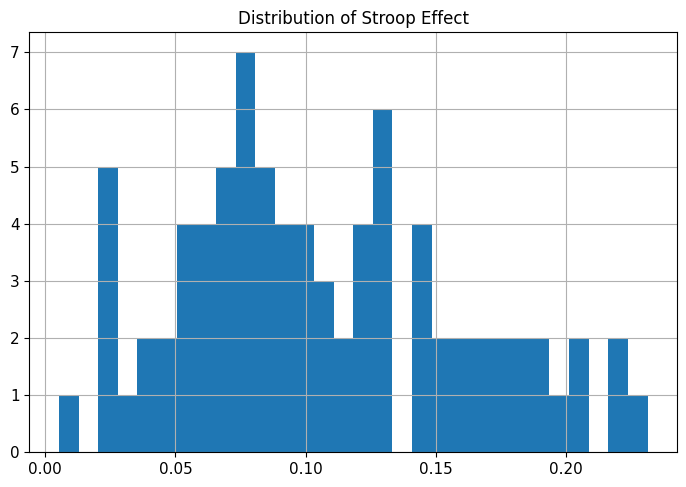

In [14]:
# Checking distribution assumptions.

plt.figure()

diff = wide["incongruent"] - wide["congruent"]

diff.hist(bins=30)

plt.title("Distribution of Stroop Effect")

plt.show()

In [15]:
# Paired t-test

t_stat, p_val = ttest_rel(
    wide["incongruent"],
    wide["congruent"]
)

print("t stat: ", t_stat, "\np value: ", p_val)

t stat:  17.76946078257321 
p value:  1.6724100536711219e-29


In [16]:
# Cohen’s dz

dz = diff.mean() / diff.std(ddof=1)

print("Cohen's dz: ", dz)

Cohen's dz:  1.9743845313970234


In [17]:
# Confidence interval

mean_diff = diff.mean()

se = diff.std(ddof=1) / np.sqrt(len(diff))

ci_low = mean_diff - 1.96 * se
ci_high = mean_diff + 1.96 * se

print(
    "Mean difference: ", mean_diff,
    "\nCI low: ", ci_low,
    "\nCI high: ", ci_high
)

Mean difference:  0.10633077438679957 
CI low:  0.09460231957614394 
CI high:  0.11805922919745519


In [18]:
# Neutral condition comparison

tt_neutral = ttest_rel(
    wide["incongruent"],
    wide["neutral"]
)

print("Neutral-incongruent t-test:\n", tt_neutral)

tt_neutral = ttest_rel(
    wide["congruent"],
    wide["neutral"]
)

print("\nNeutral-congruent t-test:\n", tt_neutral)

Neutral-incongruent t-test:
 TtestResult(statistic=np.float64(16.34556680903891), pvalue=np.float64(3.205351447104341e-27), df=np.int64(80))

Neutral-congruent t-test:
 TtestResult(statistic=np.float64(-5.982378910268387), pvalue=np.float64(5.885533151792649e-08), df=np.int64(80))


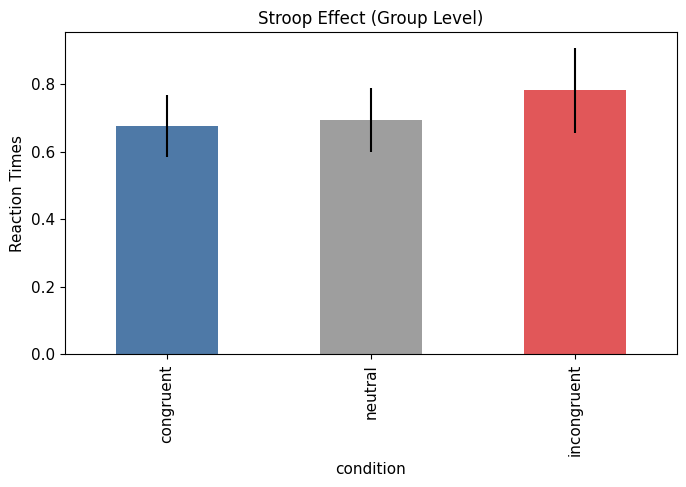

In [19]:
# Visualizing Stroop effect figure (bar plot).

means = wide[["congruent","neutral","incongruent"]].mean()
stds = wide[["congruent","neutral","incongruent"]].std()

means.plot(
    kind="bar",
    yerr=stds,
    color=[
        palette["congruent"],
        palette["neutral"],
        palette["incongruent"]
    ]
)

plt.title("Stroop Effect (Group Level)")
plt.ylabel("Reaction Times")

plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\stroop-effect-distribution-bar.png")
plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\stroop-effect-distribution-bar.pdf")

plt.show()

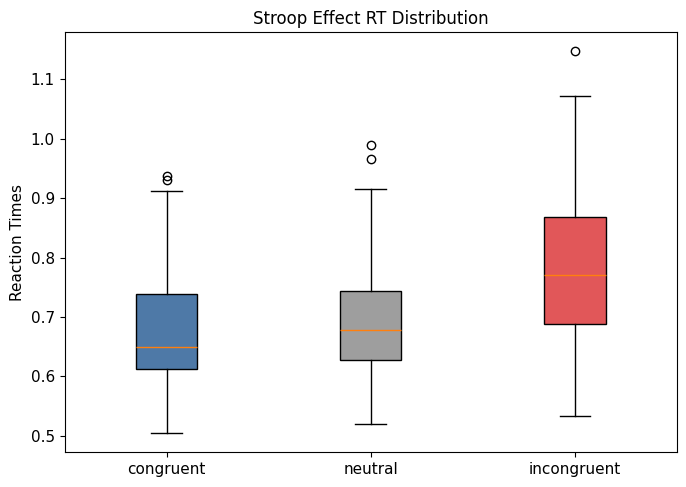

In [20]:
# Stroop by RT (boxplot)

plt.figure()

box = plt.boxplot(
    [
        wide["congruent"],
        wide["neutral"],
        wide["incongruent"]
    ],
    patch_artist=True
)

for patch, color in zip(
    box["boxes"],
    [
        palette["congruent"],
        palette["neutral"],
        palette["incongruent"]
    ]
):
    patch.set_facecolor(color)

plt.xticks([1,2,3], ["congruent","neutral","incongruent"])
plt.title("Stroop Effect RT Distribution")
plt.ylabel("Reaction Times")

plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\stroop-effect-distribution-box.png")
plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\stroop-effect-distribution-box.pdf")

plt.show()

Note:
- t(80) = 17.77
- p = 1.67 × 10^-29
- Cohen’s dz = 1.97
- Mean difference = 0.106 s
- 95% CI [0.0946, 0.1181]

Participants responded significantly slower in incongruent trials compared to congruent trials. The effect is large in magnitude (dz ~ 2.0).

In [21]:
# Checking robustness in means.

trimmed = diff[(diff > diff.quantile(0.05)) & (diff < diff.quantile(0.95))]

print("Trimmed mean: ", trimmed.mean())
print("Full mean: ", diff.mean())

Trimmed mean:  0.10457832294415866
Full mean:  0.10633077438679957


In [22]:
# Checking outlier sensitivity (RT trimming).

# Removing extreme RTs to test robustness of Stroop effect.

df_trim = df[(df["RT"] > 0.25) & (df["RT"] < 1.5)]

subj_means_trim = (
    df_trim.groupby(["subj", "condition"])["RT"]
    .mean()
    .reset_index()
)

wide_trim = subj_means_trim.pivot(
    index="subj",
    columns="condition",
    values="RT"
)

diff_trim = wide_trim["incongruent"] - wide_trim["congruent"]

# t-test

tt_trim = ttest_rel(wide_trim["incongruent"], wide_trim["congruent"])

print("t-test of trimming:\n", tt_trim)

t-test of trimming:
 TtestResult(statistic=np.float64(18.037775112902143), pvalue=np.float64(6.38836928835237e-30), df=np.int64(80))


Individual differences:
 count    81.000000
mean      0.106331
std       0.053855
min       0.005288
25%       0.069725
50%       0.097793
75%       0.146348
max       0.231218
Name: stroop_effect, dtype: float64


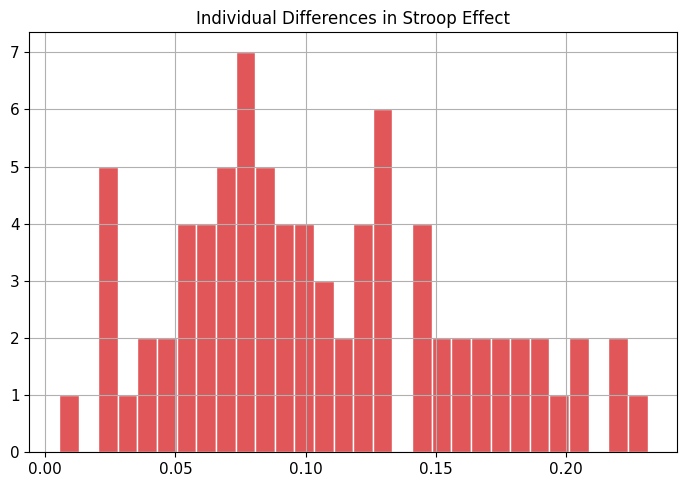

In [23]:
# Checking participant-level Stroop effect distribution.

wide["stroop_effect"] = wide["incongruent"] - wide["congruent"]

print("Individual differences:\n", wide["stroop_effect"].describe())

# Visualization

plt.figure()

wide["stroop_effect"].hist(
    bins=30,
    color=palette["effect"],
    edgecolor="white"
)

plt.title("Individual Differences in Stroop Effect")

plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\individual-difference-stroop-effect.png")
plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\individual-difference-stroop-effect.pdf")

plt.show()

In [24]:
# Robustness summary table

summary = {
    "mean_effect": diff.mean(),
    "effect_size_dz": dz,
    "t_stat": t_stat,
    "p_value": p_val,
    "n_subjects": len(diff)
}

print(summary)

# Saveing summary result.

with open(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\stroop-summary.json", "w") as f:
    json.dump(summary, f)

{'mean_effect': np.float64(0.10633077438679957), 'effect_size_dz': np.float64(1.9743845313970234), 't_stat': np.float64(17.76946078257321), 'p_value': np.float64(1.6724100536711219e-29), 'n_subjects': 81}


In [25]:
# Building participant-condition accuracy matrix.

acc_wide = (
    df.assign(
        correct_num=(df["correct"] == "correct").astype(int)
    )
    .groupby(["subj", "condition"])["correct_num"]
    .mean()
    .reset_index()
    .pivot(
        index="subj",
        columns="condition",
        values="correct_num"
    )
)

# Mean

acc_wide.mean()

# Inferential test

tt_acc = ttest_rel(
    acc_wide["congruent"],
    acc_wide["incongruent"]
)

tt_acc

TtestResult(statistic=np.float64(6.377062274466106), pvalue=np.float64(1.0849517339571943e-08), df=np.int64(80))

In [26]:
# Extracting summary metrics.

mean_congruent = acc_wide["congruent"].mean()
mean_incongruent = acc_wide["incongruent"].mean()

diff = mean_congruent - mean_incongruent

print("Congruent mean: ", mean_congruent,
      "\nIncongruent mean: ", mean_incongruent,
      "\nMean difference: ", diff)

Congruent mean:  0.9595455023822694 
Incongruent mean:  0.9305453774221334 
Mean difference:  0.029000124960136042


In [27]:
# Building condition-level RT accuracy table.

# RT descriptives

rt_desc = df.groupby("condition")["RT"].agg(
    N="count",
    mean_RT="mean",
    SD_RT="std",
    median_RT="median"
)

# Accuracy

df["correct_num"] = (df["correct"] == "correct").astype(int)

acc_desc = df.groupby("condition")["correct_num"].mean().rename("mean_accuracy")

# Merge into one table

table1 = rt_desc.join(acc_desc)

# Formatting 

table1 = table1.reset_index()

table1 = table1[[
    "condition",
    "N",
    "mean_RT",
    "SD_RT",
    "median_RT",
    "mean_accuracy"
]]

print(table1)

     condition      N   mean_RT     SD_RT  median_RT  mean_accuracy
0    congruent  16267  0.673705  0.220661   0.616448       0.958812
1  incongruent  16016  0.777901  0.266670   0.721626       0.930445
2      neutral  16218  0.690101  0.221852   0.636816       0.949377


In [28]:
# Saving condition-level RT accuracy resutls.

table1.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\table1-descriptives.csv", index=False)

In [29]:
# Building inferential results table.

table2 = pd.DataFrame({
    "comparison": ["Incongruent vs Congruent"],
    "t_statistic": [t_stat],
    "p_value": [p_val],
    "effect_size_dz": [dz],
    "ci_low": [ci_low],
    "ci_high": [ci_high]
})

print(table2)

                 comparison  t_statistic       p_value  effect_size_dz  \
0  Incongruent vs Congruent    17.769461  1.672410e-29        1.974385   

     ci_low   ci_high  
0  0.094602  0.118059  


In [30]:
# Saving inferential results.

table2.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\table2-inferential-results.csv", index=False)

In [31]:
# Testing normality with Shapiro.

diff = wide["incongruent"] - wide["congruent"]

shapiro_result = shapiro(diff)

print(shapiro_result)

ShapiroResult(statistic=np.float64(0.9706928479618359), pvalue=np.float64(0.05998523679241533))


In [32]:
# Checking distribution shape metrics.

skewness = diff.skew()
kurtosis = diff.kurtosis()

print("Skewness:", skewness, "\nKurtosis: ", kurtosis)

Skewness: 0.40998207539433706 
Kurtosis:  -0.5734564634337818


In [33]:
# Saveing assumption results.

assumption_checks = {
    "shapiro_statistic": float(shapiro_result.statistic),
    "shapiro_pvalue": float(shapiro_result.pvalue),
    "skewness": float(skewness),
    "kurtosis": float(kurtosis),
    "n_subjects": int(len(diff))
}

with open(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\assumption-checks.json", "w") as f:
    json.dump(assumption_checks, f, indent=4)

In [34]:
# Wilcoxon signed-rank test

wilcoxon_result = wilcoxon(
    wide["incongruent"],
    wide["congruent"]
)

print(wilcoxon_result)

# Extracting statistics

statistic = wilcoxon_result.statistic
p_value = wilcoxon_result.pvalue

print("Statistics: ", statistic, "\np value: ", p_value)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(5.362626265112969e-15))
Statistics:  0.0 
p value:  5.362626265112969e-15


In [35]:
# Computing per-participant trial counts.

trial_count = df.groupby("subj").size()

# Building a merged dataset form effect and exposure.

merged = wide.copy()

merged["n_trials"] = trial_count

# Analyzing correlation.

merge_corr = merged["stroop_effect"].corr(merged["n_trials"])

print("Correlation: ", merge_corr)

Correlation:  -0.061175181245883004


In [36]:
# Building participant-level table for model structure test.

participant = (wide.copy())

participant["baseline_rt"] = participant["congruent"]

participant["stroop_effect"] = (participant["incongruent"] - participant["congruent"])

print(participant[["baseline_rt", "stroop_effect"]].head())

condition  baseline_rt  stroop_effect
subj                                 
118340        0.671240       0.071976
120554        0.612650       0.067214
142272        0.623539       0.027264
142610        0.818801       0.177668
146393        0.695120       0.084534


In [37]:
# Analyzing correlation.

corr = participant["baseline_rt"].corr(
    participant["stroop_effect"]
)

print("Correlation: ", corr)

Correlation:  0.4570005474079024


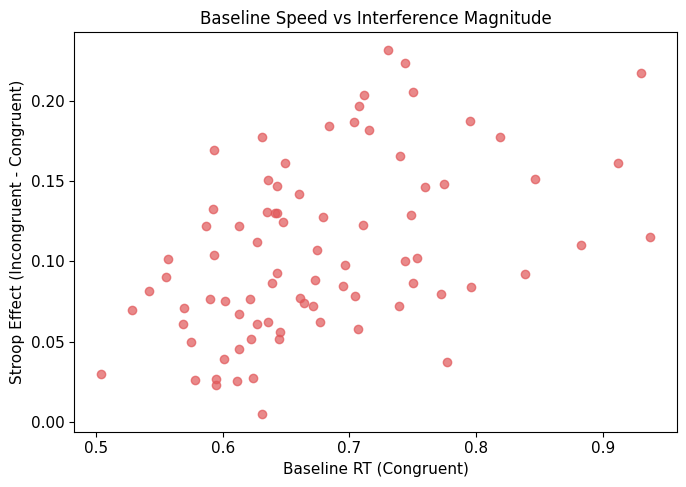

In [38]:
# Visualizing baseline vs effect.

plt.figure()

plt.scatter(
    participant["baseline_rt"],
    participant["stroop_effect"],
    color=palette["effect"],
    alpha=0.7
)

plt.xlabel("Baseline RT (Congruent)")
plt.ylabel("Stroop Effect (Incongruent - Congruent)")
plt.title("Baseline Speed vs Interference Magnitude")

plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\baseline-vs-effect.png")
plt.savefig(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\baseline-vs-effect.pdf")

plt.show()